--- Statistical Analysis ---
              upvote       downvote           if_1           if_2
count  198000.000000  198000.000000  198000.000000  198000.000000
mean        2.607975       0.666394       1.906152       7.956212
std         5.054763       2.044335      25.635752      14.839464
min         0.000000       0.000000       0.000000       3.000000
25%         0.000000       0.000000       0.000000       4.000000
50%         1.000000       0.000000       0.000000       6.000000
75%         3.000000       1.000000       4.000000      10.000000
max       201.000000     107.000000    1860.000000    1833.000000

--- Missing Values Check ---
race        145423
religion    145423
gender      145423
comment          1
dtype: int64


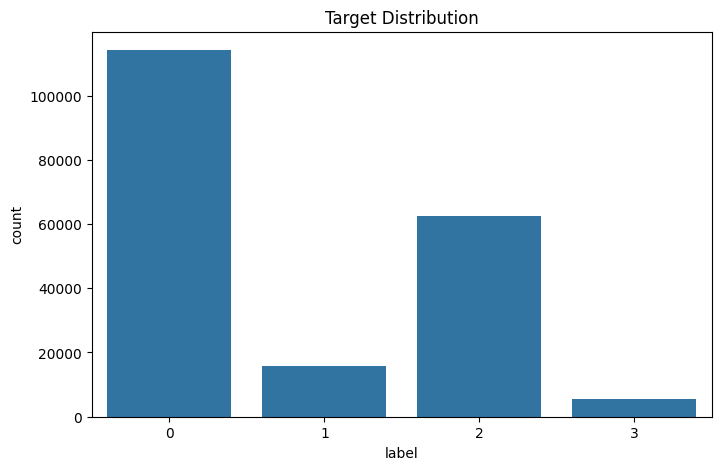

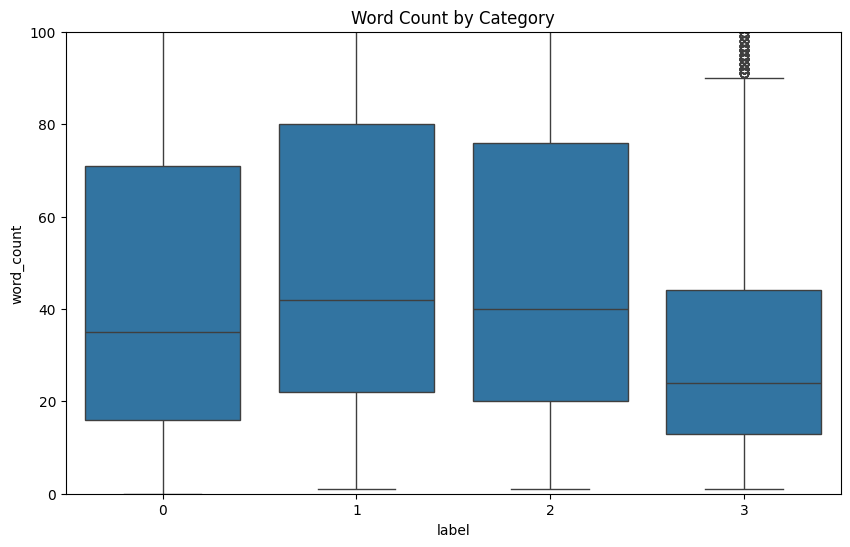

In [1]:
import pandas as pd
import numpy as np
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import ComplementNB
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
from scipy.sparse import csr_matrix

# 1 Loading dataset
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# Converting bool into 0 and 1
train_df['disability'] = train_df['disability'].astype(float)
test_df['disability'] = test_df['disability'].astype(float)

# Defining all column grouped by their data types
numeric_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_1', 'if_2', 'word_count', 'char_count', 'caps_ratio',
                'exclamation_count', 'question_count']
categorical_cols = ['race', 'religion', 'gender']
boolean_cols = ['disability']
target_col = 'label'
text_col = 'comment'

# 2. EDA
print("--- Statistical Analysis ---")
print(train_df[['upvote', 'downvote', 'if_1', 'if_2']].describe())
print("\n--- Missing Values Check ---")
print(train_df[['race', 'religion', 'gender', 'comment']].isnull().sum())

# Plotting target distribution to check for class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=train_df)
plt.title('Target Distribution')
plt.show()

# word count feature for EDA purpose
train_df['word_count'] = train_df[text_col].fillna('').astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.boxplot(x=target_col, y='word_count', data=train_df)
plt.ylim(0, 100)
plt.title('Word Count by Category')
plt.show()

# 3. Text Cleaning Func
def clean_text_simple(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', ' url ', text) # Normalize links
    text = re.sub(r'@\w+', ' user ', text)   # Normalize mentions
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Keep only alphanumeric and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

# cleaning both datasets 
train_df['clean_text'] = train_df[text_col].apply(clean_text_simple)
test_df['clean_text'] = test_df[text_col].apply(clean_text_simple)

# calculating the engineered features
# i. Word Count
train_df['word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))
test_df['word_count'] = test_df['clean_text'].apply(lambda x: len(x.split()))

# ii. Character Count
train_df['char_count'] = train_df['clean_text'].apply(len)
test_df['char_count'] = test_df['clean_text'].apply(len)

# iii. Caps Ratio Using original uncleaned comment to check for upcase
def get_caps_ratio(text):
    text = str(text)
    if len(text) == 0: return 0
    return sum(1 for c in text if c.isupper()) / len(text)

train_df['caps_ratio'] = train_df['comment'].apply(get_caps_ratio)
test_df['caps_ratio'] = test_df['comment'].apply(get_caps_ratio)

# iv. Punctuation Counts using original comment
train_df['exclamation_count'] = train_df['comment'].astype(str).apply(lambda x: x.count('!'))
test_df['exclamation_count'] = test_df['comment'].astype(str).apply(lambda x: x.count('!'))
train_df['question_count'] = train_df['comment'].astype(str).apply(lambda x: x.count('?'))
test_df['question_count'] = test_df['comment'].astype(str).apply(lambda x: x.count('?'))


# 4. Preprocessing Pipelines
# Pipeline for numeric features handle missing valuethen scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for text convert cleaned text to TF-IDF numerical vectors
text_transformer = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(analyzer='word', stop_words='english', ngram_range=(1, 2), max_features=15000, sublinear_tf=True)),
    ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), max_features=15000, sublinear_tf=True))
])

# Pipeline for categorical demographics 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline for boolean disability 
boolean_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combining to one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bool', boolean_transformer, boolean_cols),
        ('txt', text_transformer, 'clean_text')
    ])

# Spliting data to evaluate performance
X = train_df.drop(target_col, axis=1)
y = train_df[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
# # 5. Baseline model LR
# model_lr = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(solver='liblinear', C=5.0, class_weight='balanced', max_iter=1000, random_state=42))
# ])

# # training LR model
# model_lr.fit(X_train, y_train)

# # eval on validation set
# val_preds_lr = model_lr.predict(X_val)
# print(f"LR Validation Accuracy: {accuracy_score(y_val, val_preds_lr):.4f}")
# print(classification_report(y_val, val_preds_lr))

# # final training on full dataset
# model_lr.fit(X, y)
# test_preds_lr = model_lr.predict(test_df)

# # generating submission for LR
# submission_lr = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_lr['label'] = test_preds_lr
# submission_lr.to_csv('submission.csv', index=False)
# print("LR Submission file successfully generated.")

In [3]:
# # Model 2 baseline model SGD transformed into a Linear SVM using loss= hinge
# model_sgd_svm = Pipeline(steps=[
#     ('preprocessor', preprocessor), 
#     ('classifier', SGDClassifier(loss='hinge', class_weight='balanced', random_state=42, max_iter=1000))
# ])

# # tuning alpha (regularization strength) and penalty types
# param_grid_sgd_svm = {
#     'classifier__alpha': [0.0001, 0.001, 0.01],
#     'classifier__penalty': ['l2', 'elasticnet']
# }

# print("Running GridSearchCV for SGD (SVM mode)...")
# # cv=3 cross-validates 3 times for every combination
# model_sgd_svm_tuned = GridSearchCV(model_sgd_svm, param_grid_sgd_svm, cv=3, scoring='f1_macro', n_jobs=-1)

# # training SGD model
# model_sgd_svm_tuned.fit(X_train, y_train)
# print(f"Best SGD (SVM) Hyperparameters: {model_sgd_svm_tuned.best_params_}")

# # eval on validation set
# val_preds_sgd_svm = model_sgd_svm_tuned.predict(X_val)
# print(f"SGD (SVM) Validation Accuracy: {accuracy_score(y_val, val_preds_sgd_svm):.4f}")
# print(classification_report(y_val, val_preds_sgd_svm))

# # final training on full dataset
# print("Retraining best SGD model on full dataset")
# best_sgd_svm = model_sgd_svm_tuned.best_estimator_
# best_sgd_svm.fit(X, y)
# test_preds_sgd_svm = best_sgd_svm.predict(test_df)

# # generating submission for SGD (SVM)
# submission_sgd_svm = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_sgd_svm['label'] = test_preds_sgd_svm
# submission_sgd_svm.to_csv('submission.csv', index=False)
# print("SGD (SVM) Submission file successfully generated.")

In [4]:
# Model 2 tuned Linear SVM using SGD

# pipeline combining preprocessing and classifier
model_sgd_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(
        loss='modified_huber',             # smoother than hinge, helps minority classes
        class_weight='balanced',           # handles class imbalance
        random_state=42,
        max_iter=4000,                     # higher iterations for convergence
        tol=1e-4,                          # stopping tolerance
        eta0=0.01                          # required for adaptive learning rate
    ))
])

# hyperparameter grid for tuning SGD classifier
param_grid_sgd_svm = {
    'classifier__alpha': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],     # regularization strength
    'classifier__penalty': ['l2', 'elasticnet'],             # penalty types
    'classifier__l1_ratio': [0.15, 0.5, 0.85],               # elasticnet mixing parameter
    'classifier__learning_rate': ['optimal', 'adaptive']     # learning schedules
}

print("Running GridSearchCV for SGD")

# cv=4 cross-validates 4 times for every combination
model_sgd_svm_tuned = GridSearchCV(
    model_sgd_svm,
    param_grid_sgd_svm,
    cv=4,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# training SGD model
model_sgd_svm_tuned.fit(X_train, y_train)

print(f"Best SGD (SVM) Hyperparameters: {model_sgd_svm_tuned.best_params_}")

# evaluating on validation set
val_preds_sgd_svm = model_sgd_svm_tuned.predict(X_val)

print(f"SGD (SVM) Validation Accuracy: {accuracy_score(y_val, val_preds_sgd_svm):.4f}")
print(classification_report(y_val, val_preds_sgd_svm))

# retraining best SGD model on full dataset for final submission
print("Retraining best SGD model on full dataset")

best_sgd_svm = model_sgd_svm_tuned.best_estimator_

best_sgd_svm.fit(X, y)

# predicting on test dataset
test_preds_sgd_svm = best_sgd_svm.predict(test_df)

# generating submission file
submission_sgd_svm = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission_sgd_svm['label'] = test_preds_sgd_svm
submission_sgd_svm.to_csv('submission.csv', index=False)
print("SGD file successfully generated.")

Running GridSearchCV for SGD
Fitting 4 folds for each of 60 candidates, totalling 240 fits
Best SGD (SVM) Hyperparameters: {'classifier__alpha': 0.0001, 'classifier__l1_ratio': 0.15, 'classifier__learning_rate': 'adaptive', 'classifier__penalty': 'elasticnet'}
SGD (SVM) Validation Accuracy: 0.9005
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.69      0.85      0.76      3183
           2       0.89      0.87      0.88     12488
           3       0.51      0.80      0.62      1094

    accuracy                           0.90     39600
   macro avg       0.77      0.86      0.80     39600
weighted avg       0.91      0.90      0.90     39600

Retraining best SGD model on full dataset
SGD file successfully generated.


In [5]:
# # 5. Stacking Classifier
# # setting up base models
# base_models = [
#     ('lr', LogisticRegression(solver='liblinear', C=5.0, class_weight='balanced', max_iter=1000, random_state=42)),
#     ('svm', SGDClassifier(loss='hinge', alpha=0.0001, class_weight='balanced', max_iter=1000, random_state=42))
# ]

# # stacking classifier with passthrough
# stacker_best = StackingClassifier(
#     estimators=base_models,
#     final_estimator=LogisticRegression(solver='liblinear', max_iter=3000, random_state=42), 
#     cv=3,
#     passthrough=True, 
#     n_jobs=-1   
# )

# # final pipeline combining preprocessor and stacker
# model_stack_best = Pipeline(steps=[
#     ('preprocessor', preprocessor), 
#     ('stacking', stacker_best)
# ])

# print("Training Stacking Classifier")
# model_stack_best.fit(X_train, y_train)

# # evaluating on validation set
# val_preds_stack_best = model_stack_best.predict(X_val)
# print(f"Stacking Validation Accuracy: {accuracy_score(y_val, val_preds_stack_best):.4f}")
# print(classification_report(y_val, val_preds_stack_best))

# # retraining on full dataset for final submission
# print("Retraining Stacking model on full dataset")
# model_stack_best.fit(X, y)
# test_preds_stack_best = model_stack_best.predict(test_df)

# # generating submission file
# submission_stack_best = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_stack_best['label'] = test_preds_stack_best
# submission_stack_best.to_csv('submission.csv', index=False)
# print("Submission file successfully generated.")

In [6]:
# # 5. Stacking Classifier
# from sklearn.linear_model import RidgeClassifier
# from sklearn.linear_model import PassiveAggressiveClassifier
# # setting up base models
# base_models = [
#     ('lr', LogisticRegression(solver='liblinear', C=6.0, class_weight={0:1,1:2,2:1,3:3}, max_iter=2000, random_state=42)),
#     ('sgd', SGDClassifier(loss='log_loss', alpha=0.00005, class_weight={0:1,1:2,2:1,3:3}, max_iter=3000, random_state=42)),
#     ('ridge', RidgeClassifier(alpha=1.5, class_weight={0:1,1:2,2:1,3:3}, random_state=42)),
#     ('pa', PassiveAggressiveClassifier(C=0.8, class_weight={0:1,1:2,2:1,3:3}, max_iter=2000, random_state=42))
# ]

# # stacking classifier with passthrough
# stacker_best = StackingClassifier(
#     estimators=base_models,
#     final_estimator=LogisticRegression(
#         solver='liblinear',
#         C=2.5,
#         class_weight={0:1,1:2,2:1,3:3},
#         max_iter=5000,
#         random_state=42
#     ), 
#     cv=5,
#     passthrough=True, 
#     n_jobs=-1   
# )

# # final pipeline combining preprocessor and stacker
# model_stack_best = Pipeline(steps=[
#     ('preprocessor', preprocessor), 
#     ('stacking', stacker_best)
# ])

# print("Training Stacking Classifier")
# model_stack_best.fit(X_train, y_train)

# # evaluating on validation set
# val_preds_stack_best = model_stack_best.predict(X_val)
# print(f"Stacking Validation Accuracy: {accuracy_score(y_val, val_preds_stack_best):.4f}")
# print(classification_report(y_val, val_preds_stack_best))

# # retraining on full dataset for final submission
# print("Retraining Stacking model on full dataset")
# model_stack_best.fit(X, y)
# test_preds_stack_best = model_stack_best.predict(test_df)

# # generating submission file
# submission_stack_best = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_stack_best['label'] = test_preds_stack_best
# submission_stack_best.to_csv('submission.csv', index=False)
# print("Submission file successfully generated.")

In [7]:
# # Model 3
# numeric_transformer_cnb = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', MinMaxScaler())  
# ])

# # tuning the text feature extractor for naive bayes
# text_transformer_cv_tuned = CountVectorizer(
#     stop_words='english', 
#     max_features=30000, 
#     ngram_range=(1, 3), 
#     min_df=2            
# )

# # rebuilding the preprocessor
# preprocessor_cnb_tuned = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer_cnb, numeric_cols),
#         ('cat', categorical_transformer, categorical_cols),
#         ('bool', boolean_transformer, boolean_cols),
#         ('txt', text_transformer_cv_tuned, 'clean_text') 
#     ])

# # pipeline setup
# model_cnb_tuned_pipe = Pipeline(steps=[
#     ('preprocessor', preprocessor_cnb_tuned),
#     ('classifier', ComplementNB())
# ])

# # deep-dive into hyperparameters
# param_grid_cnb_deep = {
#     'classifier__alpha': [0.3, 0.4, 0.5, 0.6, 0.8],
#     'classifier__norm': [False, True]
# }

# print("Running Deep GridSearchCV for ComplementNB...")
# model_cnb_deep = GridSearchCV(model_cnb_tuned_pipe, param_grid_cnb_deep, cv=3, scoring='f1_macro', n_jobs=-1)

# # training model
# model_cnb_deep.fit(X_train, y_train)
# print(f"Best CNB Hyperparameters: {model_cnb_deep.best_params_}")

# # validation eval
# val_preds_cnb_deep = model_cnb_deep.predict(X_val)
# print(f"Validation Accuracy: {accuracy_score(y_val, val_preds_cnb_deep):.4f}")
# print(classification_report(y_val, val_preds_cnb_deep))

# # retraining on full dataset for final submission
# print("Retraining best CNB model on full dataset...")
# best_cnb = model_cnb_deep.best_estimator_
# best_cnb.fit(X, y)
# test_preds_cnb = best_cnb.predict(test_df)

# # generating submission file
# submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission['label'] = test_preds_cnb
# submission.to_csv('submission.csv', index=False)
# print("Submission file successfully generated.")

In [8]:
# # Model 4 LightGBM
# import warnings

# # silence feature name warnings for cleaner output
# warnings.filterwarnings('ignore', category=UserWarning)

# # text feature extraction using word and character TF-IDF
# text_features = FeatureUnion([
#     ('word_tfidf', TfidfVectorizer(
#         analyzer='word', stop_words='english', ngram_range=(1, 2), max_features=15000
#     )),
#     ('char_tfidf', TfidfVectorizer(
#         analyzer='char_wb', ngram_range=(3, 5), max_features=15000
#     ))
# ])

# # preprocessing pipeline combining numeric, categorical, boolean and text features
# preprocessor_lgb = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer, numeric_cols),
#         ('cat', categorical_transformer, categorical_cols),
#         ('bool', boolean_transformer, boolean_cols),
#         ('txt', text_features, 'clean_text')
#     ])

# # transform and convert to sparse csr matrix for efficient training
# X_train_transformed = preprocessor_lgb.fit_transform(X_train).astype(np.float32)
# X_val_transformed = preprocessor_lgb.transform(X_val).astype(np.float32)

# X_train_csr = csr_matrix(X_train_transformed)
# X_val_csr = csr_matrix(X_val_transformed)

# # clear intermediate arrays from memory
# del X_train_transformed, X_val_transformed
# gc.collect()

# print("Training Deep-Tuned LightGBM")

# # tuned LightGBM model for text + structured features
# lgb_model_opt = lgb.LGBMClassifier(
#     n_estimators=1200,          
#     learning_rate=0.02,         
#     num_leaves=90,              
#     max_depth=14,               
#     colsample_bytree=0.35,      
#     subsample=0.8,              
#     subsample_freq=1,           
#     reg_alpha=0.3,              
#     reg_lambda=1.5,             
#     class_weight={0:1, 1:2.5, 2:1, 3:4},
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     histogram_pool_size=2048,
#     verbose=-1
# )

# # training LightGBM model
# lgb_model_opt.fit(X_train_csr, y_train)

# # validation evaluation
# print("Evaluating model")
# val_preds_opt = lgb_model_opt.predict(X_val_csr)
# print(f"Optimized Validation Accuracy: {accuracy_score(y_val, val_preds_opt):.4f}")
# print(classification_report(y_val, val_preds_opt))

# # processing test data for final submission
# print("Processing test set for submission")
# X_test_transformed = preprocessor_lgb.transform(test_df).astype(np.float32)
# X_test_csr = csr_matrix(X_test_transformed)

# # clearing temporary memory
# del X_test_transformed
# gc.collect()

# # generating predictions
# test_preds_opt = lgb_model_opt.predict(X_test_csr)

# submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission['label'] = test_preds_opt
# submission.to_csv('submission.csv', index=False)

# print("file successfully generated")

In [9]:
# # Model 5 LightGBM
# import warnings
# import time
# import threading
# import sys
# # silence feature name warnings for cleaner output
# warnings.filterwarnings('ignore', category=UserWarning)

# # text feature extraction using word and character TF-IDF
# text_features = FeatureUnion([
#     ('word_tfidf', TfidfVectorizer(
#         analyzer='word',
#         stop_words='english',
#         ngram_range=(1,2),
#         max_features=15000,
#         min_df=3,
#         sublinear_tf=True  # Added: Logarithmic scaling
#     )),
#     ('char_tfidf', TfidfVectorizer(
#         analyzer='char_wb',
#         ngram_range=(3,6),
#         max_features=15000,
#         min_df=3,
#         sublinear_tf=True  # Added: Logarithmic scaling
#     ))
# ])

# # preprocessing pipeline combining numeric, categorical, boolean and text features
# preprocessor_lgb = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer, numeric_cols),
#         ('cat', categorical_transformer, categorical_cols),
#         ('bool', boolean_transformer, boolean_cols),
#         ('txt', text_features, 'clean_text')
#     ]
# )

# # transform and convert to sparse csr matrix
# X_train_transformed = preprocessor_lgb.fit_transform(X_train).astype(np.float32)
# X_val_transformed = preprocessor_lgb.transform(X_val).astype(np.float32)

# X_train_csr = csr_matrix(X_train_transformed)
# X_val_csr = csr_matrix(X_val_transformed)

# del X_train_transformed, X_val_transformed
# gc.collect()

# print("Training Optimized LightGBM")

# # Tuned specifically to prevent sparse matrix overfitting
# lgb_model_opt = lgb.LGBMClassifier(
#     n_estimators=1500,          # Increased trees to learn slowly
#     learning_rate=0.02,         # Slowed down the learning rate
#     num_leaves=85,              # Reduced to prevent overfitting
#     max_depth=10,               # Reduced depth
#     min_child_samples=30,       # Force it to generalize more
#     colsample_bytree=0.4,
#     subsample=0.8,
#     subsample_freq=1,
#     reg_alpha=1.0,              # Increased L1 regularization
#     reg_lambda=3.0,             # Increased L2 regularization
#     class_weight='balanced',    # Removed extreme manual weights; use auto-balance
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     verbose=-1,
#     device='gpu'                # Added GPU back for speed
# )

# # --- LIVE TIMER SETUP ---
# keep_running = True
# def live_timer():
#     start_time = time.time()
#     while keep_running:
#         elapsed = int(time.time() - start_time)
#         mins, secs = divmod(elapsed, 60)
#         sys.stdout.write(f"\r⏳ Model is running... Elapsed time: {mins}m {secs}s")
#         sys.stdout.flush()
#         time.sleep(1)

# timer_thread = threading.Thread(target=live_timer)
# timer_thread.start()

# try:
#     lgb_model_opt.fit(X_train_csr, y_train)
#     # validation evaluation
#     val_probs = lgb_model_opt.predict_proba(X_val_csr)
# finally:
#     keep_running = False
#     timer_thread.join()
#     print("\nCompleted")

# # --- AUTO-THRESHOLD OPTIMIZER ---
# print("Searching for maximum F1 score thresholds...")
# from sklearn.metrics import f1_score
# best_f1 = 0
# thresholds = [0.5, 0.5, 0.5, 0.5] # default fallback

# # Heuristic loop to find the best thresholds without overfitting
# for t0 in np.arange(0.3, 0.7, 0.1):
#     for t1 in np.arange(0.3, 0.7, 0.1):
#         for t2 in np.arange(0.3, 0.7, 0.1):
#             for t3 in np.arange(0.1, 0.5, 0.1): # Class 3 usually needs lower threshold
#                 temp_thresh = [t0, t1, t2, t3]
#                 temp_preds = []
#                 for probs in val_probs:
#                     adjusted = [p/t for p, t in zip(probs, temp_thresh)]
#                     temp_preds.append(np.argmax(adjusted))
                
#                 score = f1_score(y_val, temp_preds, average='macro')
#                 if score > best_f1:
#                     best_f1 = score
#                     thresholds = temp_thresh

# print(f"Best Dynamic Thresholds Found: {np.round(thresholds, 2)}")

# val_preds_opt = []
# for probs in val_probs:
#     adjusted = [p/t for p, t in zip(probs, thresholds)]
#     val_preds_opt.append(np.argmax(adjusted))

# val_preds_opt = np.array(val_preds_opt)

# print(f"Optimized Validation Accuracy: {accuracy_score(y_val, val_preds_opt):.4f}")
# print(classification_report(y_val, val_preds_opt))

# # processing test data for final submission
# print("Processing test set for submission")
# X_test_transformed = preprocessor_lgb.transform(test_df).astype(np.float32)
# X_test_csr = csr_matrix(X_test_transformed)

# # clearing temporary memory
# del X_test_transformed
# gc.collect()

# # generating predictions using same probability thresholding
# test_probs = lgb_model_opt.predict_proba(X_test_csr)

# test_preds_opt = []
# for probs in test_probs:
#     adjusted = [p/t for p, t in zip(probs, thresholds)]
#     test_preds_opt.append(np.argmax(adjusted))

# test_preds_opt = np.array(test_preds_opt)

# submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission['label'] = test_preds_opt
# submission.to_csv('submission.csv', index=False)

# print("file successfully generated")